### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

### Loading Data

In [2]:
URL = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
df = pd.read_csv(URL)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Preparing the dataset
Using only the following columns:

'engine_displacement'/
'horsepower' /
'vehicle_weight' /
'model_year' /
'fuel_efficiency_mpg'

In [3]:
df_small = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df_small.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

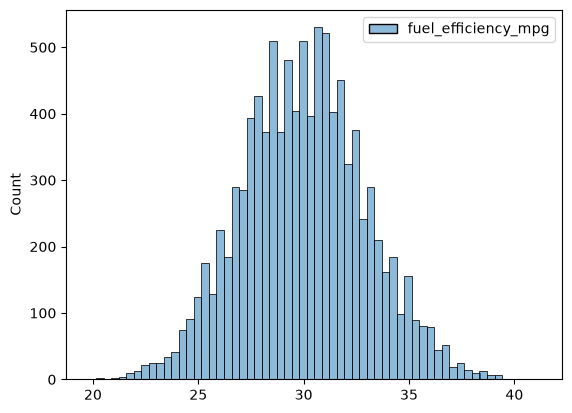

In [4]:
sns.histplot(df_small[['fuel_efficiency_mpg']])
plt.show()

# NO, it doesn't have a long tail

### Question 1
There's one column with missing values. What is it?

In [5]:
print(f'The column with missing values: {df_small.isna().sum()[df_small.isna().sum() > 0].index[0] }')

The column with missing values: horsepower


### Question 2
What's the median (50% percentile) for variable 'horsepower'?

In [6]:
print(f'Median of horsepower: {df_small['horsepower'].median()}')

Median of horsepower: 254.0


### Prepare and split the dataset

In [7]:
def prepare_X(df, val=0.0):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(value = val)
    X = df.values
    return X

In [8]:
def split_data(df, s = 42):
   n = len(df)
   
   n_val = int(n * 0.2)
   n_test = int(n * 0.2)
   n_train = n - n_val - n_test
   
   idx = np.arange(n)
   np.random.seed(s)
   np.random.shuffle(idx)
   
   df_train = df.iloc[idx[:n_train]]
   df_val = df.iloc[idx[n_train:n_train + n_val]]
   df_test = df.iloc[idx[n_train + n_val:]]

   y_train = df_train['fuel_efficiency_mpg'].values
   y_val = df_val['fuel_efficiency_mpg'].values
   y_test = df_test['fuel_efficiency_mpg'].values

   del df_train['fuel_efficiency_mpg']
   del df_val['fuel_efficiency_mpg']
   del df_test['fuel_efficiency_mpg']

   return df_train,df_val,df_test,y_train,y_val,y_test

In [9]:
df_train,df_val,df_test,y_train,y_val,y_test = split_data(df_small)

We need to deal with missing values for the column from Q1.
We have two options: fill it with 0 or with the mean of this variable.

### Option 1: Filling it with 0

This experiment without using regularization 

In [10]:
def train_linear_model(X, y, r = 0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0]) #this line does the regularization
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0],w[1:]

In [11]:
def RMSE(y_pred,y_true):
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

In [12]:
X_train_o1 = prepare_X(df_train)
X_val_o1 = prepare_X(df_val)
X_test_o1 = prepare_X(df_test)

### Training the model only on train data , then validate it using the val data

In [13]:
w0,w = train_linear_model(X_train_o1,y_train)
y_pred_o1 = w0 + X_val_o1.dot(w)
y_pred_o1

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [14]:
o1_RMSE = round(RMSE(y_pred_o1,y_val),3)
print(f'RMSE of option 1: {o1_RMSE}')

RMSE of option 1: 2.205


### Option 2 : Filling using the mean

For computing the mean, use the training only!

In [15]:
m = np.mean(df_train['horsepower'])

X_train_o2 = prepare_X(df_train,val = m)
X_test_o2 = prepare_X(df_test,val = m)
X_val_o2 = prepare_X(df_val,val = m)

### Training the model only on train data , then validate it using the val data

In [16]:
w0,w = train_linear_model(X_train_o2,y_train)
y_pred_o2 = w0 + X_val_o2.dot(w)
y_pred_o2

array([31.54288381, 29.92505122, 31.56459523, ..., 30.54408311,
       30.85701236, 31.55313717], shape=(2000,))

### Q3: Which option gives better RMSE?

In [17]:
print(f"RMSE of option 1: {round(o1_RMSE,3)}")
o2_RMSE = RMSE(y_pred_o2,y_val)
print(f"RMSE of option 2: {round(o2_RMSE,3)}")
#answer: option 2 is a little bit better

RMSE of option 1: 2.205
RMSE of option 2: 2.202


### Question 4
Now train a regularized linear regression.

For this question, fill the NAs with 0, so we gonna use the o1 data.

Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].

In [18]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
  w0,w = train_linear_model(X_train_o1, y_train, r = r)
  y_p = w0 + X_val_o1.dot(w)
  score = RMSE(y_p, y_val)
  print(f'{r}: {round(score,4)}')

#The best r is 0 

0: 2.2053
0.01: 2.2058
0.1: 2.2241
1: 2.3492
5: 2.4094
10: 2.4195
100: 2.4292


### Question 5
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.

Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

For each seed, do the train/validation/test split with 60%/20%/20% distribution.

Fill the missing values with 0 and train a model without regularization

For each seed, evaluate the model on the validation dataset and collect the RMSE scores.

In [19]:
scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = split_data(df_small, s=seed)

    X_train = prepare_X(df_train)
    X_val = prepare_X(df_val)
    X_test = prepare_X(df_test)

    w0,w = train_linear_model(X_train,y_train)
    y_p = w0 + X_val.dot(w)
    
    score = RMSE(y_p,y_val)
    scores.append(score)

What's the standard deviation of all the scores?

In [20]:
std = np.std(scores)

Round the result to 3 decimal digits

In [21]:
print(f'the standard deviation of all the scores: {round(std,3)}')

the standard deviation of all the scores: 0.029


### Question 6

Split the dataset like previously, use seed 9.

In [22]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df_small, s=9)

Combine train and validation datasets.

In [23]:
df_full_train = pd.concat([df_train,df_val])

Fill the missing values with 0 and train a model with r=0.001

In [24]:
X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train,y_val])

w0,w = train_linear_model(X_full_train, y_full_train,r = 0.001)

What's the RMSE on the test dataset?

In [25]:
X_test = prepare_X(df_test)

y_pred = w0 + X_test.dot(w)
print(f'RMSE: {round(RMSE(y_pred,y_test),3)}')

RMSE: 2.236
